In [1]:
import mosaique as mq
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras


ModuleNotFoundError: No module named 'mosaique'

In [71]:
# importing sys
import sys
# This is how you import modules that exist outside of working directory 
# adding scripts to the system path
sys.path.insert(1, '/workspaces/QML-QPF/scripts')

# all the imports

import json
from Filters import Filters
from Data_load import data_load

from Model import Model

import matplotlib.pyplot as plt

from utils import *

import time

## Now we need to get the data using our class Data_Load

In [72]:
# Set the environment for asynchronous GPU usage
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [73]:
from medmnist import DermaMNIST
train_data = DermaMNIST(split="train", download=True,size=64)
val_data = DermaMNIST(split="val", download=True,size=64)

In [74]:
train_images, train_labels, val_images, val_labels = train_data.imgs, train_data.labels, val_data.imgs, val_data.labels

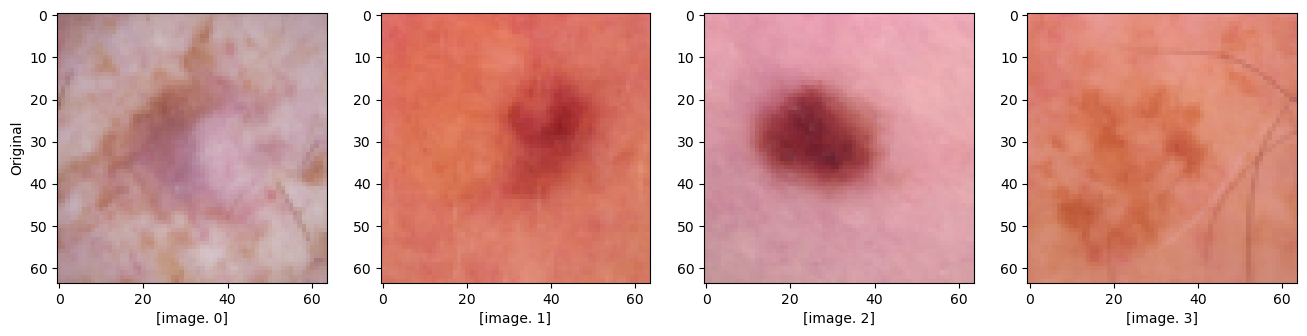

In [75]:
# Vizualise the image before filtering


# vizualise the filtered images:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot all output channels for quantum cnot find TensorRT
axes[0].set_ylabel("Original")
for c in range(4):
    axes[c].set_xlabel("[image. {}]".format(c))
    axes[c].imshow(train_images[c, :, :])

In [76]:
train_images[0].shape
print(np.max(train_images[0,:,:]), np.max(train_images[0,:,:,2]))

213 201


In [77]:
# Using Min Max Normalization technique
# Might use other Normalization techniques to see if it affects the performance.
def normalize_image(img, image_height, image_width, image_depth):
    '''Normalize pixel values within 0 and 1'''
    # image_height, image_width, image_depth = img.shape
    # normalized_img filled with zeros initially with same shape as omg input
    normalized_img = np.zeros((image_height, image_width, image_depth))  

    max_pixel, min_pixel  = np.max(img), np.min(img)
    # Add epsilon to avoid division by zero
    epsilon = 1e-8
    # Normalize pixel values within 0 and 1
    normalized_img = (img - min_pixel)/(max_pixel - min_pixel + epsilon)  
    
    return normalized_img 

In [78]:
def normalize_dataset(dataset):
    '''Normalize pixels values of the entire dataset'''
    sample_size, image_height, image_width, image_depth = dataset.shape
    # normalized_dataset filled with zeros initially with same shape as our input dataset
    normalized_dataset = np.zeros((sample_size, image_height, image_width, image_depth))
    for i, image in enumerate(dataset):
        normalized_dataset[i,:,:,:] = normalize_image(image, image_height, image_width, image_depth)
    
    return normalized_dataset



In [79]:
image_height, image_width, image_depth = train_images[0].shape
im1 = normalize_image(train_images[0], image_height, image_width, image_depth)
print(np.min(im1))

0.0


In [80]:
# select a few images for 
train_images = train_images[0:10, :, :]
val_images = val_images[0:5, :, :]

In [81]:
# Normalized Train dataset
train_images = normalize_dataset(train_images)
val_images = normalize_dataset(val_images)

In [82]:
train_images[0].shape

(64, 64, 3)

In [83]:
val_images

tensor([[[[0.95132743, 0.57079646, 0.58849558],
          [0.95132743, 0.57522124, 0.57964602],
          [0.96017699, 0.5840708 , 0.59734513],
          ...,
          [0.96017699, 0.57079646, 0.59734513],
          [0.95575221, 0.57079646, 0.59734513],
          [0.95132743, 0.57522124, 0.59292035]],

         [[0.9380531 , 0.55752212, 0.57522124],
          [0.95132743, 0.57964602, 0.59734513],
          [0.96460177, 0.5840708 , 0.60619469],
          ...,
          [0.95132743, 0.56637168, 0.57079646],
          [0.95575221, 0.57522124, 0.59292035],
          [0.94247788, 0.57964602, 0.59292035]],

         [[0.9380531 , 0.55752212, 0.59734513],
          [0.95575221, 0.57964602, 0.61061947],
          [0.96017699, 0.5840708 , 0.60619469],
          ...,
          [0.94247788, 0.55309735, 0.55752212],
          [0.94247788, 0.56637168, 0.57522124],
          [0.94247788, 0.57522124, 0.58849558]],

         ...,

         [[0.89823009, 0.57079646, 0.51769912],
          [0.90265487,

## building the quantum circuit

In [84]:
import pennylane as qml

dev = qml.device("default.qubit", wires=nb_qbits)


def circuit( phi, meas_last, dev):
    n_qubits = len(phi)

    @qml.qnode(dev)
    def qnode():
        # Encoding part
        for j in range(n_qubits):
            qml.RY(np.pi * phi[j], wires=j)

        # Filter from arxiv.org/abs/2308.14930
        qml.CNOT(wires=[0, 2])
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[1, 2])

        if meas_last is True:    # measure only the last qubit if meas_last is set to True
            return [qml.expval(qml.PauliZ(n_qubits-1))]
        else:
            return [qml.expval(qml.PauliZ(j)) for j in range(n_qubits)]

    # print(qml.draw(qnode)())
    # print(qml.draw_mpl(qnode)())
    return qnode()

In [85]:
%matplotlib inline
print(qml.draw(circuit, show_all_wires=True)([0.1/np.pi,0.2/np.pi,0.3/np.pi], False, dev))


## Now lets check which pixel of the images goes to each wire on the quantum circuit

In [86]:
def quantum_conv_filter(image, meas_last=False):
        image_height, image_width = image.shape[0], image.shape[1]
        
        stride = 1

        # measure only the last qubit (useful if all qubits are entangled)
        if meas_last is True:
            n_channels = 1
        else:
            n_channels = 3
        # what is this and what is doing
        # out = np.zeros((image_height // 2, image_width // 2, n_channels))

        # I will use the same shape as my input images i.e (64,64,3)
        out = np.zeros((image_height, image_width, n_channels))
        print(out)
        dev = qml.device('default.qubit', wires=nb_qbits )

        for j in range(0, image_height, stride):
            for k in range(0, image_width, stride):
                q_results = circuit([
                                        image[j, k, 0],
                                        image[j, k, 1],
                                        image[j, k, 2],
                                    ],
                                    meas_last,
                                    dev
                                    )
                #print(f'({j}, {k}),   ({j+1}, {k }), ({j}, {k+1}),  ({j + 1}, {k + 1})')

                # This is why I don't get correct results I need to understand this
                for c in range(len(q_results)):
                    #print('q_results' ,q_results)
                    print('j , k , c', j , k , c)
                    # I'm changing the output as well
                    out[j , k , c] = q_results[c]
        return out

In [87]:
train_images[0]


tensor([[[0.55223881, 0.2238806 , 0.23880597],
         [0.56716418, 0.26119403, 0.29850746],
         [0.56716418, 0.24626866, 0.30597015],
         ...,
         [0.7761194 , 0.58208955, 0.65671642],
         [0.76119403, 0.56716418, 0.64925373],
         [0.75373134, 0.55223881, 0.62686567]],

        [[0.57462687, 0.25373134, 0.28358209],
         [0.57462687, 0.25373134, 0.29850746],
         [0.58955224, 0.28358209, 0.32089552],
         ...,
         [0.7761194 , 0.58208955, 0.6641791 ],
         [0.76865672, 0.56716418, 0.64925373],
         [0.74626866, 0.54477612, 0.59701493]],

        [[0.58208955, 0.23880597, 0.29104478],
         [0.58208955, 0.23134328, 0.2761194 ],
         [0.59701493, 0.29104478, 0.30597015],
         ...,
         [0.78358209, 0.58208955, 0.65671642],
         [0.7761194 , 0.57462687, 0.62686567],
         [0.76119403, 0.55970149, 0.59701493]],

        ...,

        [[0.7238806 , 0.47014925, 0.54477612],
         [0.73134328, 0.5       , 0.56716418]

In [88]:
filtered = quantum_conv_filter(train_images[0], meas_last=False)

[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 ...

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  ...
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]
j , k , c 0 0 0
j , k , c 0 0 1
j , k , c 0 0 2
j , k , c 0 1 0
j , k , c 0 1 1
j , k , c 0 1 2
j , k , c 0 2 0
j , k , c 0 2 1
j , k , c 0 2 2
j , k , c 0 3 0
j , k , c 0 3 1
j , k , c 0 3 2
j , k , c 0 4 0
j , k , c 0 4 1
j , k , c 0 4 2
j , k , c 0 5 0
j , k , c 0 5 1
j , k , c 0 5 2
j , k , c 0 6 0
j , k , c 0 6 1
j , k , c 0 6 2
j , k , c 0 7 0
j , k , c 0 7 1
j , k , c 0 7 2
j , k , c 0 8 0
j , k , c 0 8 1
j , k , c 0 8 2
j , k , c 0 9 0
j , k , c 0 9 1
j , k , c 0 9 

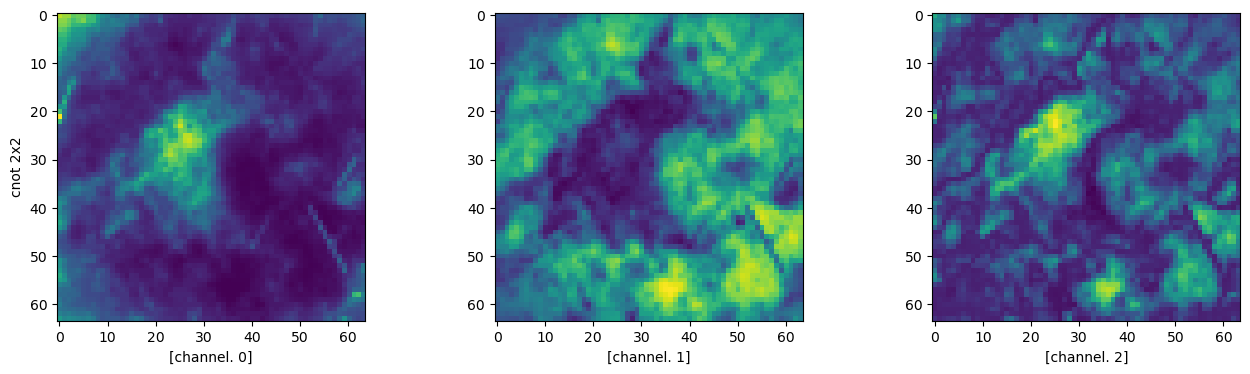

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot all output channels for quantum cnot find TensorRT
axes[0].set_ylabel("cnot 2x2")
for c in range(3):
    axes[c].set_xlabel("[channel. {}]".format(c))
    axes[c].imshow(filtered[:, :, c])